# 分類機の精度指標

In [73]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import f1_score, roc_curve, auc
from scipy.stats import hmean
from sklearn.preprocessing import label_binarize

In [2]:
# データロード
df = sns.load_dataset('iris')

In [3]:
y_col ='species'
X = df.drop(columns=[y_col])
y = df[y_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# モデル学習
model = LogisticRegression(penalty=None)
model.fit(X_train, y_train)
# 予測
y_pred = model.predict(X_test)

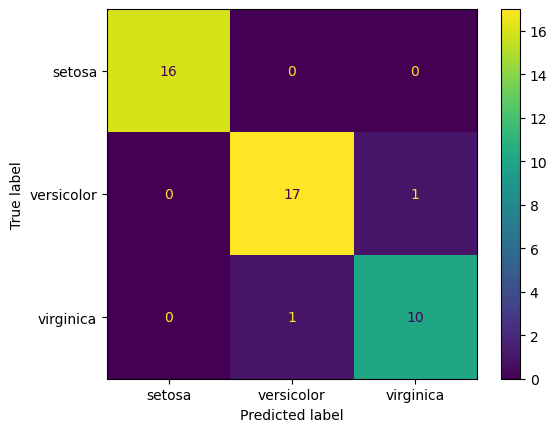

In [4]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

# Accuracy

In [5]:
# サンプルデータ
y_true = [1, 1, 0, 1, 0, 0, 1, 1]
y_pred = [1, 1, 1, 0, 0, 1, 0, 1]

In [6]:
accuracy_score(y_true, y_pred)

0.5

# Precision

In [7]:
precision_score(y_true, y_pred)

0.6

# Recall

In [8]:
recall_score(y_true, y_pred)

0.6

# Specificity

In [9]:
np.array(y_true)!=1
recall_score(np.array(y_true)!=1, np.array(y_pred)!=1)

0.3333333333333333

# 多クラス評価におけるPrecision

In [10]:
# データロード
df = sns.load_dataset('iris')
y_col ='species'
X = df.drop(columns=[y_col])
y = df[y_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# モデル学習
model = LogisticRegression(penalty=None)
model.fit(X_train, y_train)
# 予測
y_pred = model.predict(X_test)

In [11]:
# average=None
print(precision_score(y_test, y_pred, average=None))

# average=macro
print(precision_score(y_test, y_pred, average='macro'))

# average=micro
print(precision_score(y_test, y_pred, average='micro'))

# same as acuracy
print(accuracy_score(y_test, y_pred))

[1.         0.94444444 0.90909091]
0.9511784511784511
0.9555555555555556
0.9555555555555556


In [12]:
model.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [13]:
df = pd.read_csv('heart_preprocessed.csv')
y_col = 'target'
X = df.drop(columns=[y_col])
y = df[y_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# モデルの学習
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

In [14]:
y_pred_proba[:10]

array([[0.49557281, 0.50442719],
       [0.28325102, 0.71674898],
       [0.99733358, 0.00266642],
       [0.06907229, 0.93092771],
       [0.4793277 , 0.5206723 ],
       [0.99002568, 0.00997432],
       [0.66307307, 0.33692693],
       [0.79308362, 0.20691638],
       [0.30219419, 0.69780581],
       [0.30219419, 0.69780581]])

In [15]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])

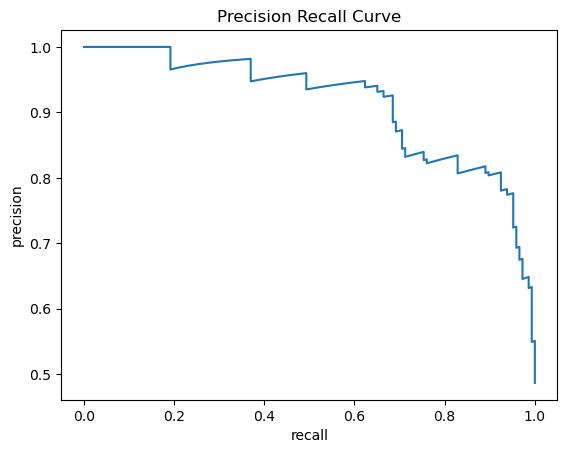

In [16]:
plt.plot(recall, precision)
plt.xlabel('recall')
plt.ylabel('precision')
plt.title('Precision Recall Curve')
plt.show()

# F値

In [67]:
# サンプルデータ
y_true = [1, 0, 0, 1, 0, 0, 1, 1]
y_pred = [1, 1, 1, 0, 0, 1, 0, 1]
f1_score(y_true, y_pred)

0.4444444444444445

In [18]:
# 調和平均 ver
hmean([recall_score(y_true, y_pred), precision_score(y_true, y_pred)])

0.4444444444444444

In [19]:
recall_score(y_true, y_pred)

0.5

In [20]:
precision_score(y_true, y_pred)

0.4

## Threshhold vs Precision, Recall, Fscore

In [38]:
f1_scores = [hmean([p, r]) for p, r in zip(precision, recall)]

89th thresholds(=0.44) is the highest f1_score = 0.86


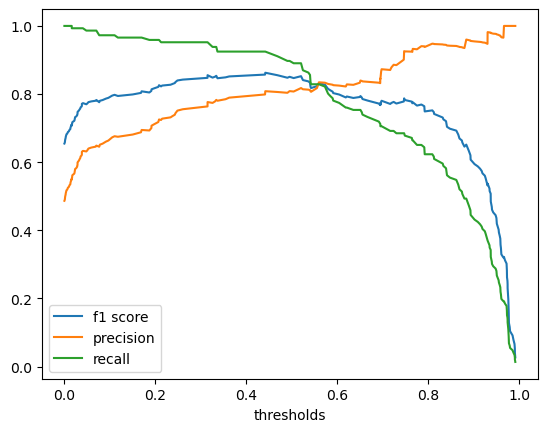

In [55]:
# 描画
plt.plot(thresholds, f1_scores[:-1], label='f1 score')
plt.plot(thresholds, precision[:-1], label='precision')
plt.plot(thresholds, recall[:-1], label='recall')
plt.xlabel('thresholds')
plt.legend()
print(f'{np.argmax(f1_scores)}th thresholds(={thresholds[np.argmax(f1_scores)]:.2f}) is the highest f1_score = {np.max(f1_scores):.2f}')

In [47]:
np.argmax(f1_scores)

89

# ROC

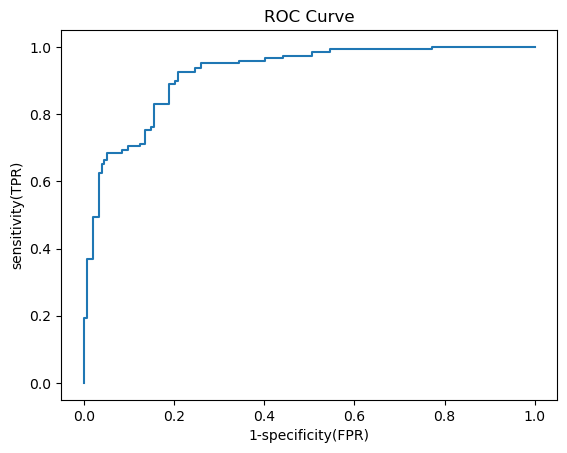

In [65]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
# 描画
plt.plot(fpr, tpr)
plt.xlabel('1-specificity(FPR)')
plt.ylabel('sensitivity(TPR)')
plt.title('ROC Curve')
plt.show()

In [68]:
auc(fpr, tpr)

0.9196762141967622

# 多クラスROC

In [80]:
# データ準備
df = sns.load_dataset('iris')
y_col ='species'
X = df.drop(columns=[y_col])
y = df[y_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# モデル学習
model = LogisticRegression()
model.fit(X_train, y_train)
# 予測
y_pred_proba = model.predict_proba(X_test)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# macro平均

In [87]:
# y_testをone-hotの形にする
y_test_one_hot = label_binarize(y_test, classes=model.classes_)

# 準備
n_classes = len(model.classes_)
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

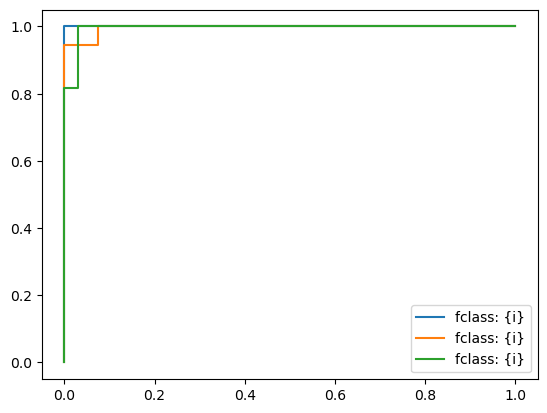

In [82]:
# それぞれのクラスのROC
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='fclass: {i}')
    plt.legend()

# np.interpの例

In [83]:
all_x = np.arange(7)
data_x = [0, 2, 5, 6]
data_y = [0, 2, 4, 6]
np.interp(all_x, data_x, data_y)

array([0.        , 1.        , 2.        , 2.66666667, 3.33333333,
       4.        , 6.        ])

array([0.        , 0.02941176, 0.07407407, 1.        ])

In [89]:
# 必要なxの値のリスト
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
# 線形補完
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr = mean_tpr / n_classes

fpr['macro'] = all_fpr
tpr['macro'] = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])



{0: array([0., 0., 0., 1.]),
 1: array([0.        , 0.        , 0.        , 0.07407407, 0.07407407,
        1.        ]),
 2: array([0.        , 0.        , 0.        , 0.02941176, 0.02941176,
        1.        ]),
 'macro': array([0.        , 0.02941176, 0.07407407, 1.        ])}

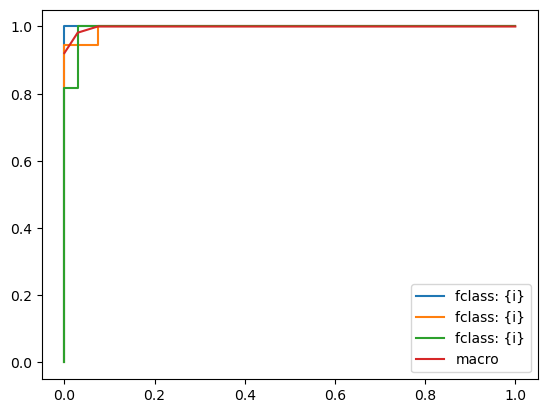

In [92]:
# それぞれのクラスとmacro平均のROC
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='fclass: {i}')
plt.plot(fpr['macro'], tpr['macro'], label='macro')
plt.legend()

## micro平均

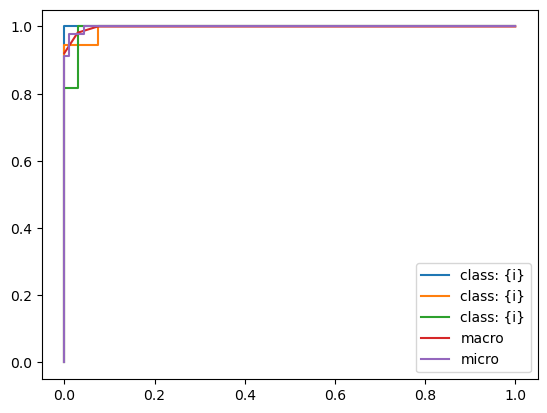

In [98]:
fpr['micro'], tpr['micro'], _ = roc_curve(y_test_one_hot.ravel(), y_pred_proba.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])
# それぞれのクラスとmicro平均のROC
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='class: {i}')
plt.plot(fpr['macro'], tpr['macro'], label='macro')
plt.plot(fpr['micro'], tpr['micro'], label='micro')
plt.legend()